# **NLP Medical Question Filtering**


***
# 0. Setup

## Imports & Utilities

In [1]:
# General imports
import os
from datetime import datetime
import time

import pandas as pd
import numpy as np
from pathlib import Path
import pickle
import uuid

# Plots
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# Embedding
from sentence_transformers import SentenceTransformer

# Scikit Learn
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import matthews_corrcoef, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

# Tensorflow, Keras
import tensorflow as tf 
import keras_tuner as kt


In [2]:
# Utility for dataset summary
#

def display_file_summary(data_frame, name=""):
    # Create a temporary df and ensure no lists remain, so that unique items can be identified for uniqueness
    temp_df = data_frame.copy()
    temp_df = temp_df.map(lambda cell: str(cell) if isinstance(cell, list) else cell)
    
    # Calculate Data Types 
    summary_of_df = pd.DataFrame({'Count': data_frame.count(),
                                 'Missing': data_frame.isnull().sum(), 'Empty': 0,
                                 'Unique': temp_df.nunique(),
                                 'Top': data_frame.apply(lambda x: x.value_counts().index[0]),
                                 'Freq': data_frame.apply(lambda x: x.value_counts().iat[0]),
                                 'Type': data_frame.dtypes, 
                                 'String': 0, 'Int': 0, 'Float': 0, 'Bool': 0, 'List': 0, 'Other': 0
                                 })
    # ?? Below with Map should not work as counting entire data frame, but counts do appear correct
    #test = data_frame['Description'].apply(lambda cell: isinstance(cell, str)).sum()
    summary_of_df['Empty'] = (data_frame == '').sum()
    summary_of_df['String'] = data_frame.map(lambda cell: isinstance(cell, str)).sum()
    summary_of_df['Int'] = data_frame.map(lambda cell: isinstance(cell, int)).sum()
    summary_of_df['Float'] = data_frame.map(lambda cell: isinstance(cell, float)).sum()
    summary_of_df['Bool'] = data_frame.map(lambda cell: isinstance(cell, bool)).sum()
    summary_of_df['List'] = data_frame.map(lambda cell: isinstance(cell, list)).sum()
    summary_of_df['Other'] = data_frame.map(lambda cell: isinstance(cell, (tuple,dict,set,type(None)))).sum()

    print(f'File Details. {name}')
    display(summary_of_df)

## Project Setup

In [3]:
# Project Setup
#

#---- Run Parameters --------------------------------
run_name = 'Test_Training_v1'

#----------------------------------------------------

# Folder paths
local_project_folder = Path.cwd().parent
data_folder = local_project_folder.joinpath('Data')
if not data_folder.exists():
    raise FileNotFoundError(f'{data_folder} does not exist')
run_results_folder = local_project_folder.joinpath(f'Results/{run_name}')
if not run_results_folder.exists():
    raise FileNotFoundError(f'{run_results_folder} does not exist')

del local_project_folder, data_folder, run_name

***
# NN Model Training

## General Functions

In [4]:
# Model Details
#

def inspect_model(model):

    print(f'\n{model.summary()}')    
    for i, layer in enumerate(model.layers):
        print(f"\nLayer {i}: {layer.name} ({type(layer).__name__})")
        print(f"  - Input shape: {layer.input_shape}")
        print(f"  - Output shape: {layer.output_shape}")
        
        # Show activation function for layers that have it
        if hasattr(layer, 'activation'):
            print(f"  - Activation: {layer.activation.__name__}")
            
        # Show units for Dense layers
        if hasattr(layer, 'units'):
            print(f"  - Units: {layer.units}")
            
        # Show other layer-specific attributes
        if hasattr(layer, 'kernel_initializer') and layer.kernel_initializer is not None:
            print(f"  - Kernel initializer: {layer.kernel_initializer.__class__.__name__}")
            
        # Show parameter count for this layer
        if hasattr(layer, 'count_params'):
            print(f"  - Parameters: {layer.count_params():,}")

In [5]:
# Model Evaluation
#

def evaluate_model(model, X_test, y_test, verbose=True):

    # Model predictions
    start_time = time.perf_counter()
    y_pred_probs = model.predict(X_test)
    # y_pred = (y_pred_probs > 0.5).astype(int).flatten()
    y_pred = np.argmax(y_pred_probs, axis=1) 
    duration = time.perf_counter() - start_time

    # Calculate Metrics
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    recall = metrics.recall_score(y_true=y_test, y_pred=y_pred, pos_label=1)
    precision = metrics.precision_score(y_true=y_test, y_pred=y_pred, pos_label=1)
    f1_score = metrics.f1_score(y_true=y_test, y_pred=y_pred, pos_label=1)
    specificity = tn / (tn + fp)
    mcc = matthews_corrcoef(y_test, y_pred)

    # Print Metrics
    if verbose:
        print(f'\n----Evaluation Result for: {model.name} -------')
        print(f'Recall (Sensitivity, TP Rate): {recall:.4f}')
        print(f'Precision: {precision:.4f}')
        print(f'F1 Score {f1_score:.4f}')
        print(f'Specificity (1 - Fall-Out): {specificity:.4f}')
        print(f'MCC: {mcc:.4f}')
        print('-----------')
        print(f'Accuracy: {metrics.accuracy_score(y_true=y_test, y_pred=y_pred):.4f}')
        print(f'Fall Out (FPR): {fp / (fp + tn):.4f}')
        print(f'Hamming Loss {metrics.hamming_loss(y_true=y_test, y_pred=y_pred):.4f}')
        # roc_auc_score = metrics.roc_auc_score(y_true=y_test, y_score=y_pred_probs.flatten())
        roc_auc_score = metrics.roc_auc_score(y_true=y_test, y_score=y_pred_probs[:, 1])
        print(f'ROC-AUC Score {roc_auc_score:.4f}')
        gini_score = 2 * roc_auc_score - 1
        print(f'Gini Index: {gini_score:.4f}')
        print('-----------')

    # Plot Confusion Matrix & ROC Curve
    if verbose:
        plt.style.use('default')
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18,6))
        fig.suptitle(f'Model Prediction Evaluation', fontsize=20)

        axes[0].set_title('Confusion Matrix')    
        # class_labels = ['Unsafe', 'Safe']
        class_labels = ['Non-Medical', 'Medical']
        ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels).plot(ax=axes[0])
        axes[1].set_title('ROC Curve')
        # roc_display = RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[1], pos_label=1)
        # RocCurveDisplay.from_predictions(y_test, y_pred_probs.flatten(), ax=axes[1], pos_label=1)
        RocCurveDisplay.from_predictions(y_test, y_pred_probs[:, 1], ax=axes[1], pos_label=1)

        plt.tight_layout()
        plt.show()
        plt.style.use('ggplot')


In [6]:
# Get original query, labels and compare to predictions
#

def query_predictions(query_dataset_df, ref_ids, X, model):

    # Map back on queries by ref-id
    query_mapping = query_dataset_df[['ref-id', 'query', 'query-label-expert', 'query-is-non-medical']].set_index('ref-id').to_dict('index')

    # Combine actual and predictions
    # 'Non-Medical' (1) and 'Medical' (0)
    predictions = model.predict(X)
    predictions_bool = np.argmax(predictions, axis=1).astype(bool)

    results = []
    for i, ref_id in enumerate(ref_ids):
        query_text = query_mapping[ref_id]['query']
        query_label_expert = query_mapping[ref_id]['query-label-expert']
        non_medical_actual = query_mapping[ref_id]['query-is-non-medical']
        non_medical_predicted = predictions_bool[i]

        results.append({
            # 'ref_id': ref_id,
            'query': query_text,
            'query-label-expert': query_label_expert,
            'query-is-non-medical-actual': non_medical_actual, 
            'query-is-non-medical-predicted': non_medical_predicted,
            # 'pred_prob': predictions[i][0]
        })
    
    return pd.DataFrame(results)


In [7]:
# Compare Predictions
#

def compare_predictions(query_predictions_df):

    misclassified_df = query_predictions_df[query_predictions_df['query-is-non-medical-predicted'] != query_predictions_df['query-is-non-medical-actual']]
    non_medical_predicted = len(query_predictions_df[query_predictions_df['query-is-non-medical-predicted']==True])

    print(f'Predictions - Non-Medical: {non_medical_predicted} out of {len(query_predictions_df)}')
    print(f'Predictions - Misclassified: {len(misclassified_df)} out of {len(query_predictions_df)}')
    print('Example Misclassifications')
    display(misclassified_df.head(10))


## Load & Split Data

In [8]:
# Load the full dataset & split
# NB: Train, Validate, Test split assuming no K-fold validation
#

# Load the saved dataset with query and embeddings
query_df = pd.read_pickle(run_results_folder.joinpath('query_data_embeddings.pkl'))

# Select features, X and target y
X = np.vstack(query_df['query-embedding'].values)
y = query_df['query-is-non-medical'].to_numpy().astype(np.float32)  # Convert bool to float32

# Ref for later mapping
ref_ids = query_df['ref-id'].values

# Train, validate, test split 60:20:20
# NB: Classes are possibly imbalanced so use stratification
X_train, X_temp, y_train, y_temp, ids_train, ids_temp = train_test_split(X, y, ref_ids, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test, ids_val, ids_test = train_test_split(X_temp, y_temp, ids_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Full df shape: {query_df.shape}")
print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")
print(f"Ref ids: {ref_ids.shape}")

del X, y, X_temp, y_temp, ids_temp

Full df shape: (2916, 5)
Training set: (1749, 384), (1749,)
Validation set: (583, 384), (583,)
Test set: (584, 384), (584,)
Ref ids: (2916,)


In [9]:
# PCA
#

from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ("center", StandardScaler(with_mean=True, with_std=False)),
    # ("pca", PCA(n_components=0.80, svd_solver="full", random_state=42)),
    ("pca", PCA(n_components=30, svd_solver="full", random_state=42)), # ?? this reduces to 41% explained variance ... but better model
])

# Fit to X_train and then transform val, test
# TODO: ANTONIO combines ALL X and fits to that?!
X_train_pca = pipe.fit_transform(X_train)
X_val_pca = pipe.transform(X_val)
X_test_pca = pipe.transform(X_test)

print('Dimensions. Train, val, test')
print("Original", X_train.shape[1], X_val.shape[1], X_test.shape[1])
print("Reduced", X_train_pca.shape[1], X_val_pca.shape[1], X_test_pca.shape[1])
print("Explained variance ratio (sum):", pipe.named_steps["pca"].explained_variance_ratio_.sum())

# Save pipeline for later use with the NN model
# import joblib
# joblib.dump(pipe, "pca_embeddings_pipeline.joblib")
# Reload with NN model
# pipe = joblib.load("pca_embeddings_pipeline.joblib")
# X_new_pca = pipe.transform(X_new)

Dimensions. Train, val, test
Original 384 384 384
Reduced 30 30 30
Explained variance ratio (sum): 0.4104342436699232


In [10]:
# Put X,y data into more efficient tf datasets
#

input_dimensions = X_train_pca.shape[1]
train_dataset_tf = tf.data.Dataset.from_tensor_slices((X_train_pca, y_train.astype(np.float32)))
val_dataset_tf = tf.data.Dataset.from_tensor_slices((X_val_pca, y_val.astype(np.float32)))
# test_dataset_tf = tf.data.Dataset.from_tensor_slices((X_test_pca, y_test.astype(np.float32)))

# Shuffle, batch etc to improve gradient descent, efficiency ...
buffer_size = len(X_train) + len(X_val) + len(X_test)
batch_size = 64

train_dataset_tf = train_dataset_tf.shuffle(buffer_size=buffer_size)
train_dataset_tf = train_dataset_tf.batch(batch_size)
val_dataset_tf = val_dataset_tf.batch(batch_size)
val_dataset_tf = val_dataset_tf.prefetch(1)
# test_dataset_tf = test_dataset_tf.batch(batch_size)
# test_dataset_tf = test_dataset_tf.prefetch(1)

print(train_dataset_tf)
print(val_dataset_tf)
# print(test_dataset_tf)

<_BatchDataset element_spec=(TensorSpec(shape=(None, 30), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 30), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


## NN Model Training - Simple

In [11]:
# Simple Model Build
# 

# TODO: Try with three output classifications?

def build_model(input_size):

    initializer = tf.keras.initializers.GlorotUniform(seed=42)
    model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(input_size)),
            tf.keras.layers.Dense(128, activation='relu', kernel_initializer=initializer),
            tf.keras.layers.Dense(2, activation='linear', kernel_initializer=initializer, name='output')
            # tf.keras.layers.Dense(2, activation='softmax', kernel_initializer=initializer, name='output')
        ], name='medical_safety_classifier')
    
    optimizer = tf.keras.optimizers.Adam()
    # TODO: logits changed from ANTONIO ie softmax + false, linear + true .... and makes adifference to precision etc
    # loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    metrics = [tf.keras.metrics.SparseCategoricalAccuracy()]

    model.compile(optimizer=optimizer, loss=loss_fn, metrics=metrics)

    return model


Epoch 1/30


2025-09-30 09:52:49.302904: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [1749]
	 [[{{node Placeholder/_1}}]]
2025-09-30 09:52:49.303116: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [1749]
	 [[{{node Placeholder/_1}}]]


28/28 [==============================] - 0s 3ms/step - loss: 0.6716 - sparse_categorical_accuracy: 0.6592 - val_loss: 0.6248 - val_sparse_categorical_accuracy: 0.9108
Epoch 2/30
28/28 [==============================] - 0s 694us/step - loss: 0.5804 - sparse_categorical_accuracy: 0.9274 - val_loss: 0.5328 - val_sparse_categorical_accuracy: 0.9468
Epoch 3/30
28/28 [==============================] - 0s 756us/step - loss: 0.4821 - sparse_categorical_accuracy: 0.9411 - val_loss: 0.4298 - val_sparse_categorical_accuracy: 0.9537
Epoch 4/30
 1/28 [>.............................] - ETA: 0s - loss: 0.4430 - sparse_categorical_accuracy: 0.9375

2025-09-30 09:52:49.532327: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2025-09-30 09:52:49.608187: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [583]
	 [[{{node Placeholder/_1}}]]


28/28 [==============================] - 0s 724us/step - loss: 0.3834 - sparse_categorical_accuracy: 0.9428 - val_loss: 0.3381 - val_sparse_categorical_accuracy: 0.9537
Epoch 5/30
28/28 [==============================] - 0s 886us/step - loss: 0.3035 - sparse_categorical_accuracy: 0.9440 - val_loss: 0.2692 - val_sparse_categorical_accuracy: 0.9520
Epoch 6/30
28/28 [==============================] - 0s 680us/step - loss: 0.2479 - sparse_categorical_accuracy: 0.9445 - val_loss: 0.2236 - val_sparse_categorical_accuracy: 0.9520
Epoch 7/30
28/28 [==============================] - 0s 768us/step - loss: 0.2128 - sparse_categorical_accuracy: 0.9457 - val_loss: 0.1944 - val_sparse_categorical_accuracy: 0.9537
Epoch 8/30
28/28 [==============================] - 0s 707us/step - loss: 0.1903 - sparse_categorical_accuracy: 0.9463 - val_loss: 0.1760 - val_sparse_categorical_accuracy: 0.9554
Epoch 9/30
28/28 [==============================] - 0s 782us/step - loss: 0.1764 - sparse_categorical_accuracy:

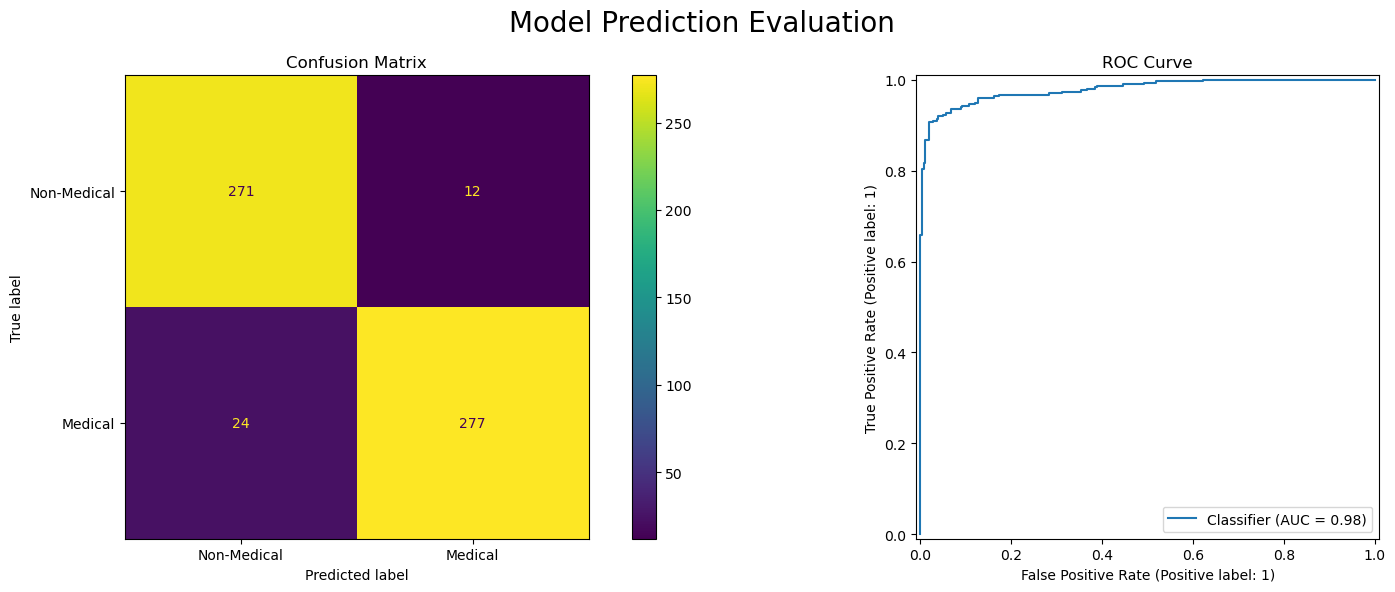

In [12]:
# Simple Model Train & Evaluate & Predictions
#

# Build and train the model
# NB: This doesn't attempt to find the best eopch/hyperparameters .. just trains on combined train + val
embedding_dimensions = input_dimensions
epochs = 30 

simple_model = build_model(input_size=embedding_dimensions)
simple_model.fit(train_dataset_tf, epochs=epochs, validation_data=val_dataset_tf)
inspect_model(simple_model)

# Evaluate the model
# evaluate_model(simple_model, X_val_pca, y_val)
evaluate_model(simple_model, X_test_pca, y_test)


In [13]:
# Map Predictions back to original query text
#

query_predictions_df = query_predictions(query_df, ids_test, X_test_pca, simple_model)
compare_predictions(query_predictions_df)

# Save the predictions and model
query_predictions_df.to_pickle(run_results_folder.joinpath('simple_model_query_predictions.pkl'))
simple_model.save(run_results_folder.joinpath('simple_model.keras'))

# loaded_model = tf.keras.models.load_model(run_results_folder.joinpath('simple_model.keras'))

19/19 [==============================] - 0s 2ms/step
Predictions - Non-Medical: 289 out of 584
Predictions - Misclassified: 36 out of 584
Example Misclassifications


,query,query-label-expert,query-is-non-medical-actual,query-is-non-medical-predicted
38,How close to death was I?,1,False,True
59,ELI5 How Name Brand Medications And Other Prod...,999,True,False
60,Why does my scalp get itchy when I eat spicy f...,999,True,False
64,What circumstances make death instant?,1,False,True
68,"Nurses/doctors of reddit, what is the most hum...",999,True,False
77,Is the book Wheat Belly pseudoscience?,999,True,False
83,How can I gain weight?,1,False,True
104,What is blood pressure ?,1,False,True
108,What would cause charlie horses in feet when y...,1,False,True
136,Everything going fast and sounds are loud,1,False,True


## NN Model - Tuned

In [14]:
# Model Builder - hyperparameter tuning with Keras Tuner
#

def model_builder(hp, input_size, model_name):

    model = tf.keras.Sequential(name=model_name)
    initializer = tf.keras.initializers.GlorotUniform(seed=42)

    # Input layer
    model.add(tf.keras.layers.Input(shape=(input_size,)))

    # Hidden layers - number of layers and neurons etc per layer is tuneable
    num_layers = hp.Int('num_layers', min_value=0, max_value=3)
    for i in range(num_layers):
        model.add(tf.keras.layers.Dense(
            units = hp.Int(f'units_{i}', min_value=8, max_value=128, step=8),
            activation = hp.Choice(f'activation_{i}', ['relu', 'tanh', 'elu']),
            kernel_initializer=initializer))
    
    # Add regularisaration to last layer
    if hp.Boolean('dropout'):
        model.add(tf.keras.layers.Dropout(
            rate=hp.Float('dropout_rate', min_value=0.0, max_value=0.5, step=0.1),
            seed=42))

    # Output layer
    model.add(tf.keras.layers.Dense(2, 
        activation='linear', 
        kernel_initializer=initializer,
        name='output'))

    # Optimiser and learning rate
    learning_rate = hp.Choice('learning_rate', values=[0.01, 0.001, 0.0001])    # default:0.001
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    # Loss function and metrics
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    # loss_fn = tf.keras.losses.BinaryCrossentropy()
    # metrics = [tf.keras.metrics.BinaryAccuracy()]
    metrics = [tf.keras.metrics.SparseCategoricalAccuracy()]
    # metrics = [tf.keras.metrics.SparseCategoricalAccuracy(), tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]

    # Build the model
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=metrics)
    
    return model

In [15]:
# Inspect Hyperparameters after tuning
#

def inspect_hypperparams(hpys):
    print(f"\nBest hyperparameters:")
    print(f"Number of layers: {hpys.get('num_layers')}")
    print(f"Learning rate: {hpys.get('learning_rate')}")
    print(f"Dropout: {hpys.get('dropout')}")
    if hpys.get('dropout'):
        print(f"Dropout rate: {hpys.get('dropout_rate')}")

    # Print units and activation for each layer
    num_layers = hpys.get('num_layers')
    for i in range(num_layers):
        print(f"Layer {i}: units={hpys.get(f'units_{i}')}, activation={hpys.get(f'activation_{i}')}")

In [16]:
# Model Train & Evaluate - hyperparameter tuning
#

# TODO: Change objective to use recall or F1 to better catch false 'safe' ... but this is an fp!?!?

# Hyperparameter search
embedding_dimensions = input_dimensions
model_name = 'medical_safety_classifier_tuned'

# tuner = kt.Hyperband(model_builder,
tuner = kt.Hyperband(lambda hp: model_builder(hp, input_size=embedding_dimensions, model_name=model_name),
                     objective='val_sparse_categorical_accuracy',
                     max_epochs=10,
                     factor=2,
                     directory=run_results_folder,
                     project_name='kt_hyper_tuning')
tuner.search(train_dataset_tf, epochs=50, validation_data=val_dataset_tf)

# Best Hyperparameters inspect
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
inspect_hypperparams(best_hps)


Trial 46 Complete [00h 00m 01s]
val_sparse_categorical_accuracy: 0.9571183323860168

Best val_sparse_categorical_accuracy So Far: 0.9622641801834106
Total elapsed time: 00h 00m 23s

Best hyperparameters:
Number of layers: 3
Learning rate: 0.01
Dropout: False
Layer 0: units=56, activation=tanh
Layer 1: units=8, activation=relu
Layer 2: units=8, activation=relu


Epoch 1/8


2025-09-30 09:53:50.761474: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [1749]
	 [[{{node Placeholder/_1}}]]
2025-09-30 09:53:50.761740: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_12' with dtype float and shape [583]
	 [[{{node Placeholder/_12}}]]


38/38 [==============================] - 0s 1ms/step - loss: 0.2934 - sparse_categorical_accuracy: 0.9001
Epoch 2/8
38/38 [==============================] - 0s 572us/step - loss: 0.1878 - sparse_categorical_accuracy: 0.9301
Epoch 3/8
38/38 [==============================] - 0s 563us/step - loss: 0.1559 - sparse_categorical_accuracy: 0.9485
Epoch 4/8
38/38 [==============================] - 0s 656us/step - loss: 0.1534 - sparse_categorical_accuracy: 0.9443
Epoch 5/8
38/38 [==============================] - 0s 589us/step - loss: 0.1477 - sparse_categorical_accuracy: 0.9468
Epoch 6/8
38/38 [==============================] - 0s 518us/step - loss: 0.1492 - sparse_categorical_accuracy: 0.9477
Epoch 7/8
38/38 [==============================] - 0s 614us/step - loss: 0.1447 - sparse_categorical_accuracy: 0.9494
Epoch 8/8
38/38 [==============================] - 0s 501us/step - loss: 0.1442 - sparse_categorical_accuracy: 0.9481
Model: "medical_safety_classifier_tuned"
___________________________

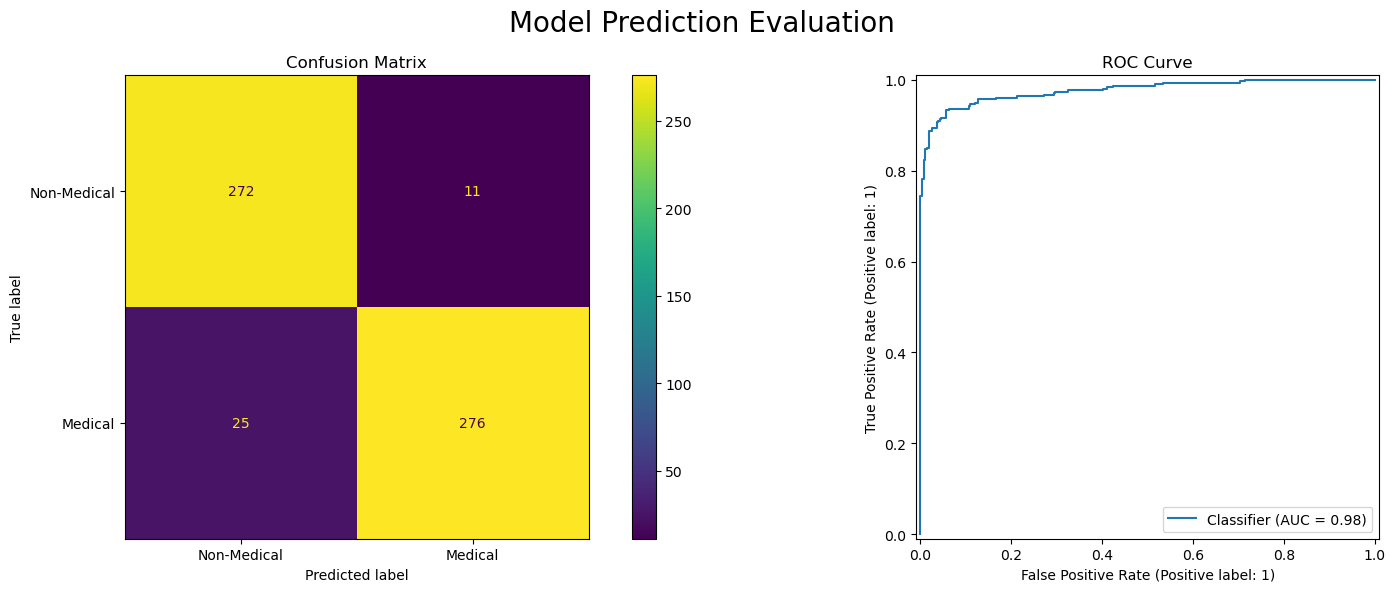

In [17]:
# Best model train and evaluate
#

# Fully train using the best hyperparameters
tuned_model = model_builder(best_hps, input_size=embedding_dimensions, model_name=model_name)
merged_train_val = train_dataset_tf.concatenate(val_dataset_tf)
tuned_model.fit(merged_train_val, epochs=8) 
# tuned_model.fit(train_dataset_tf, epochs=32, validation_data=val_dataset_tf)
inspect_model(tuned_model)

# Evaluate the model
# evaluate_model(tuned_model, X_val_pca, y_val)
evaluate_model(tuned_model, X_test_pca, y_test)


In [18]:
# Map Predictions back to original query text
#

query_predictions_df = query_predictions(query_df, ids_test, X_test_pca, tuned_model)
compare_predictions(query_predictions_df)

# Save the predictions and model
query_predictions_df.to_pickle(run_results_folder.joinpath('tuned_model_query_predictions.pkl'))
simple_model.save(run_results_folder.joinpath('tuned_model.keras'))

# loaded_model = tf.keras.models.load_model(run_results_folder.joinpath('simple_model.keras'))

19/19 [==============================] - 0s 377us/step
Predictions - Non-Medical: 287 out of 584
Predictions - Misclassified: 36 out of 584
Example Misclassifications


,query,query-label-expert,query-is-non-medical-actual,query-is-non-medical-predicted
17,How to feed my fish when I'm gone?? Help!,999,True,False
38,How close to death was I?,1,False,True
59,ELI5 How Name Brand Medications And Other Prod...,999,True,False
60,Why does my scalp get itchy when I eat spicy f...,999,True,False
64,What circumstances make death instant?,1,False,True
68,"Nurses/doctors of reddit, what is the most hum...",999,True,False
77,Is the book Wheat Belly pseudoscience?,999,True,False
82,How much would you trust the info on treadmill...,1,False,True
83,How can I gain weight?,1,False,True
104,What is blood pressure ?,1,False,True


## Adversarial Attack

In [ ]:
# Core PGD Attack Generation - Using Hyperrectangles
#

def pgd_attack_batch(model, X_batch, y_batch, pgd_steps, eps, gamma):
    """
    Performs PGD attack on a batch of inputs.

    Args:
        model: The model to attack.
        x_batch: Batch of input data.
        y_batch: Batch of true labels.
        pgd_steps: Number of PGD steps.
        eps: Tuple containing (lower bounds, upper bounds) for each dimension from hyperrectangles.
        gamma: Step size for each PGD iteration.

    Returns:
        perturbed_x: Adversarial examples generated from the input batch.
    """

    # Make a copy of the input to avoid modifying the original data
    X_adv = tf.identity(X_batch)
    
    # Iterate the PGD
    for _ in range(pgd_steps):
        with tf.GradientTape() as tape:
            tape.watch(X_adv)                   # Records all operations, watches for gradient calc
            predictions = model(X_adv)          # Forward pass, prediction on current example
            predictions = tf.squeeze(predictions)   # Ensure 1D array
            loss = tf.keras.losses.binary_crossentropy(y_batch, predictions)
        
        # Compute gradient of the loss w.r.t the input
        gradients = tape.gradient(loss, X_adv)
        
        # Apply perturbation based on sign of the gradient
        # TODO: Better understand how this maximises the loss?
        signed_grad = tf.sign(gradients)
        X_adv = X_adv + gamma * signed_grad

        # Project back within the epsilon bounds .... an epsilon ball with eps
        # perturbation = X_adv - X_batch
        # perturbation = tf.clip_by_value(perturbation, -eps, eps)
        # NB used this in image labs: x_adv = tf.clip_by_value(x_adv, x - epsilon, x + epsilon)
        # X_adv = X_batch + perturbation

        # Project back within the epsilon bounds ..... hyperrectangle with upper and lower bounds
        X_adv = tf.clip_by_value(X_adv, eps[0], eps[1]) 
        # print(eps[0], eps[1])

        # Then ensure values stay between 0 and 1
        # TODO: Is this appropriate for embedding vectors that may be outside these bounds??
        # X_adv = tf.clip_by_value(X_adv, 0.0, 1.0) 

    return X_adv

In [ ]:
# Create random hyperrectangles based on embeddings
#

def generate_hyperrectangles(embedding_data, num_rectangles):

    # Min and max bounds for each dimension
    min_bounds = np.min(embedding_data, axis=0)
    max_bounds = np.max(embedding_data, axis=0)
    dimensions_num = len(min_bounds)
    
    # Create hyperrectangles, with random bounds
    hyperrectangles = []
    for _ in range(num_rectangles):
        lower = min_bounds + np.random.random(dimensions_num) * (max_bounds - min_bounds) * 0.5
        upper = lower + np.random.random(dimensions_num) * (max_bounds - lower) * 0.9

        hyperrectangles.append(np.stack([lower, upper]))
    
    return np.array(hyperrectangles)


In [ ]:
# Simple Adversarial attack
#

# TODO: Using the hyperrectangle for eps appears to make the X_adv converge??
# TODO: Hyperrectangle generation doesn't look right??

model = simple_model
pgd_steps = 10

# Use a single hyperrectangle for eps bounds

# t_hyperrectangle = tf.squeeze(tf.transpose(hyperrectangles))
# eps = tf.transpose(hyperrectangles[0])
# eps_lower = hyperrectangles[0][0]
# eps_upper = hyperrectangles[0][1]
# eps = (eps_lower, eps_upper)
# gamma = tf.reduce_max(eps_upper - eps_lower) / 10

hyperrectangles = generate_hyperrectangles(X_test, num_rectangles=1)
eps = hyperrectangles[0]
# eps = (-0.6, 0.6)
gamma = tf.reduce_max(eps[1] - eps[0]) / 10
gamma = tf.cast(gamma, tf.float64)

# Generate adversarial examples & evaluate the model using these
X_test_adv = pgd_attack_batch(model, X_test, y_test, pgd_steps, eps=eps, gamma=gamma)
evaluate_model(simple_model, X_test_adv, y_test)

# Examine predictions
query_predictions_df = query_predictions(query_dataset_df, ids_test, X_test_adv, simple_model)
compare_predictions(query_predictions_df)


## WIP

In [ ]:
# Generate adversarial attacks
#

model = simple_model

# Create random hyperrectangles with bounds of actual embeddings
hyperrectangles = generate_hyperrectangles(X_test, num_rectangles=5)
hyperrectangles_labels = np.full(len(hyperrectangles), 0)

# For each hyperrectangle, generate PGD vectors and labels
pgd_dataset = None
pgd_labels = None
for _, hyperrectangle in enumerate(hyperrectangles):

    # Get the lower and upper bounds for each dimension
    t_hyperrectangle = tf.transpose(hyperrectangle)


    # Run the PGD attack to generate adversarial examples
    X_adv = pgd_attack_batch(model, X_test, y_test, pgd_steps=10, eps=(-1,2), gamma=0.1 )

    if pgd_dataset is not None:
        pgd_dataset = tf.concat([pgd_dataset, pgd_point], axis=0)
        pgd_labels = tf.concat([pgd_labels, pgd_label], axis=0)
    else:
        pgd_dataset = pgd_point
        pgd_labels = pgd_label

# Evaluate the model
evaluate_model(simple_model, X_test_adv, y_test)

# Examine & Save Predictions
query_predictions_df = query_predictions(query_dataset_df, ids_test, X_test_adv, simple_model)
compare_predictions(query_predictions_df)


In [ ]:
# hyperrectangles, hyperrectangles_labels = get_hyperrectangles()
pgd_dataset = None
pgd_labels = None

model = simple_model
pgd_steps = 5
gamma_multiplier = 1000

for i, hyperrectangle in enumerate(hyperrectangles):
    # Extract the min and max bounds for each dimension (eps), transpose the hyperrectangle
    t_hyperrectangle = tf.transpose(hyperrectangle)
    # t_hyperrectangle = tf.transpose(tf.cast(hyperrectangle, tf.float32))


    # Calculate gamma (step size) from the hyperrectangle bounds
    gamma = tf.expand_dims((t_hyperrectangle[1] - t_hyperrectangle[0]) / (pgd_steps * gamma_multiplier), axis=0)

    # Generate random points in hyperrectangles
    pgd_point = tf.random.uniform(shape=[1, t_hyperrectangle.shape[-1]],
                                              minval=t_hyperrectangle[0],
                                              maxval=t_hyperrectangle[1])
    pgd_label = tf.expand_dims(hyperrectangles_labels[i], axis=0)

    # Run the PGD attack to generate adversarial examples
    pgd_point = pgd_attack_batch(model, pgd_point, pgd_label, pgd_steps, t_hyperrectangle, gamma)

    if pgd_dataset is not None:
        pgd_dataset = tf.concat([pgd_dataset, pgd_point], axis=0)
        pgd_labels = tf.concat([pgd_labels, pgd_label], axis=0)
    else:
        pgd_dataset = pgd_point
        pgd_labels = pgd_label

### xxxx

In [ ]:
def evaluate_attack(self, original_embeddings, adversarial_embeddings, 
                       true_labels, attack_name="Attack"):
        """
        Evaluate the success of adversarial attacks
        """
        # Get predictions for original and adversarial examples
        original_preds = tf.argmax(self.model(original_embeddings), axis=1)
        adversarial_preds = tf.argmax(self.model(adversarial_embeddings), axis=1)

        # Calculate attack success rate
        original_accuracy = tf.reduce_mean(
            tf.cast(original_preds == true_labels, tf.float32)
        )
        adversarial_accuracy = tf.reduce_mean(
            tf.cast(adversarial_preds == true_labels, tf.float32)
        )

        attack_success_rate = tf.reduce_mean(
            tf.cast(original_preds != adversarial_preds, tf.float32)
        )

        # Calculate perturbation statistics
        perturbation = adversarial_embeddings - original_embeddings
        l2_norm = np.mean(np.linalg.norm(perturbation, axis=1))
        linf_norm = np.mean(np.max(np.abs(perturbation), axis=1))

        results = {
            'original_accuracy': float(original_accuracy),
            'adversarial_accuracy': float(adversarial_accuracy),
            'attack_success_rate': float(attack_success_rate),
            'avg_l2_perturbation': l2_norm,
            'avg_linf_perturbation': linf_norm
        }

        print(f"\n{attack_name} Results:")
        print(f"Original Accuracy: {results['original_accuracy']:.4f}")
        print(f"Adversarial Accuracy: {results['adversarial_accuracy']:.4f}")
        print(f"Attack Success Rate: {results['attack_success_rate']:.4f}")
        print(f"Average L2 Perturbation: {results['avg_l2_perturbation']:.6f}")
        print(f"Average L∞ Perturbation: {results['avg_linf_perturbation']:.6f}")

        return results

### Hyperparameter tuning

In [ ]:
# Quick without a rebuild

model_best_tuned = tuner.hypermodel.build(best_hps)
model_best_tuned.fit(train_dataset_tf, epochs=50, validation_data=test_dataset_tf)



In [ ]:
# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
model_temp = tuner.hypermodel.build(best_hps)
history = model_temp.fit(train_dataset_tf, epochs=50, validation_data=test_dataset_tf)

val_acc_per_epoch = history.history['val_binary_accuracy']
best_epoch = val_acc_per_epoch.index(max(val_acc_per_epoch)) + 1
print('Best epoch: %d' % (best_epoch,))

# Temp# Create a DataFrame with test queries and predictionstest_results_df = pd.DataFrame({    'query': X_text_test,    'actual_label': y_test,    'actual_safe': ["Safe" if label == 1 else "Unsafe" for label in y_test],    'predicted_prob': y_pred_probs.flatten(),    'predicted_binary': (y_pred_probs > 0.5).astype(int).flatten(),    'predicted_safe': ["Safe" if prob > 0.5 else "Unsafe" for prob in y_pred_probs.flatten()],    'correct_prediction': (y_test == (y_pred_probs > 0.5).astype(int).flatten())})print(f"Test results DataFrame shape: {test_results_df.shape}")print("\nFirst 5 rows:")display(test_results_df.head())

# Inspect queries and predictions - on the test dataset split
print(f"Correct predictions: {test_results_df['correct_prediction'].sum()}/{len(test_results_df)} ({test_results_df['correct_prediction'].mean():.3f})")

# Quick look at queries and predictions
for i in range(min(15, len(y_pred_probs))):
    query = X_text_test[i]
    actual_flag = "Safe" if y_test[i] == 1 else "Unsafe"
    predicted_prob = y_pred_probs[i][0]

# Predicted probabilities
y_pred_probs = simple_model.predict(X_test)

# Create a DataFrame with test queries and predictions
test_results_df = pd.DataFrame({    'query': X_text_test,    'actual_label': y_test,    'actual_safe': ["Safe" if label == 1 else "Unsafe" for label in y_test],    'predicted_prob': y_pred_probs.flatten(),    'predicted_binary': (y_pred_probs > 0.5).astype(int).flatten(),    'predicted_safe': ["Safe" if prob > 0.5 else "Unsafe" for prob in y_pred_probs.flatten()],    'correct_prediction': (y_test == (y_pred_probs > 0.5).astype(int).flatten())})print(f"Test results DataFrame shape: {test_results_df.shape}")print("\nFirst 5 rows:")
display(test_results_df.head())

print("\nPrediction accuracy summary:")
print(f"Correct predictions: {test_results_df['correct_prediction'].sum()}/{len(test_results_df)} ({test_results_df['correct_prediction'].mean():.3f})")

# Save the results DataFrame
test_results_df.to_pickle(data_folder.joinpath('test_results_with_predictions.pkl'))
print("\nSaved test results to 'test_results_with_predictions.pkl'")

# Quick look at queries and predictions
for i in range(min(15, len(y_pred_probs))):
    query = X_text_test[i]
    actual_flag = "Safe" if y_test[i] == 1 else "Unsafe"
    predicted_prob = y_pred_probs[i][0]

    print(f"{query}")
    print(f"- Actual: {actual_flag} vs Predicted: {predicted_prob:.2f}")

#
